# Active Learning with Gated-GP

<!-- $_{Yongtao}$ $_{Liu,}$  
$_{youngtaoliu@gmail.com}$

$_{Feb}$ $_{2024}$ -->

### Install and Import

In [ ]:
import numpy as np
np.__version__

In [4]:

# import numpy as np
import time
import h5py

import pyNSID
import matplotlib.pyplot as plt
# import numba

import sidpy
#Let's open up a sample dataset and see...

import SciFiReaders as sr
from scipy.optimize import curve_fit
import numpy as np



def SHO_fit_flattened(wvec,*p):
    Amp, w_0, Q, phi=p[0],p[1],p[2],p[3]
    func = Amp * np.exp(1.j * phi) * w_0 ** 2 / (wvec ** 2 - 1j * wvec * w_0 / Q - w_0 ** 2)
    return np.hstack([np.real(func),np.imag(func)])

def SHO_fit_abs(wvec,*p):
    Amp, w_0, Q, phi=p[0],p[1],p[2],p[3]
    func = Amp * np.exp(1.j * phi) * w_0 ** 2 / (wvec ** 2 - 1j * wvec * w_0 / Q - w_0 ** 2)
    return np.abs(func)

def my_guess_fn(freq_vec,ydata):
    ydata = np.array(ydata)
    amp_guess = np.abs(ydata)[np.argmax(np.abs(ydata))]
    Q_guess = 50
    max_min_ratio = np.max(abs(ydata)) / np.min(abs(ydata))
    phi_guess = np.angle(ydata)[np.argmax(np.abs(ydata))]
    w_guess = freq_vec[np.argmax(np.abs(ydata))]
    
    #Let's just run some Q values to find the closest one
    Q_values = [5,10,20,50,100,200,500]
    err_vals = []
    for q_val in Q_values:
        p_test = [amp_guess/q_val, w_guess, q_val, phi_guess]
        func_out = SHO_fit_flattened(freq_vec,*p_test)
        complex_output = func_out[:len(func_out)//2] + 1j*func_out[(len(func_out)//2):] 
        amp_output = np.abs(complex_output)
        err = np.mean((amp_output - np.abs(ydata))**2)
        err_vals.append(err)
    Q_guess = Q_values[np.argmin(err_vals)]
    p0 = [amp_guess/Q_guess, w_guess, Q_guess, phi_guess]
    return p0


#Complex Gaussian Guess function
from numpy import exp, abs, sqrt, sum, real, imag, arctan2, append

def SHOestimateGuess(w_vec, resp_vec, num_points=5):
    """
    Generates good initial guesses for fitting

    Parameters
    ------------
    w_vec : 1D numpy array or list
        Vector of BE frequencies
    resp_vec : 1D complex numpy array or list
        BE response vector as a function of frequency
    num_points : (Optional) unsigned int
        Quality factor of the SHO peak

    Returns
    ---------
    retval : tuple
        SHO fit parameters arranged as amplitude, frequency, quality factor, phase
    """

    ii = np.argsort(abs(resp_vec))[::-1]

    a_mat = np.array([])
    e_vec = np.array([])
    
    for c1 in range(num_points):
        for c2 in range(c1 + 1, num_points):
            w1 = w_vec[ii[c1]]
            w2 = w_vec[ii[c2]]
            X1 = real(resp_vec[ii[c1]])
            X2 = real(resp_vec[ii[c2]])
            Y1 = imag(resp_vec[ii[c1]])
            Y2 = imag(resp_vec[ii[c2]])

            denom = (w1 * (X1 ** 2 - X1 * X2 + Y1 * (Y1 - Y2)) + w2 * (-X1 * X2 + X2 ** 2 - Y1 * Y2 + Y2 ** 2))
            if denom > 0:
                a = ((w1 ** 2 - w2 ** 2) * (w1 * X2 * (X1 ** 2 + Y1 ** 2) - w2 * X1 * (X2 ** 2 + Y2 ** 2))) / denom
                b = ((w1 ** 2 - w2 ** 2) * (w1 * Y2 * (X1 ** 2 + Y1 ** 2) - w2 * Y1 * (X2 ** 2 + Y2 ** 2))) / denom
                c = ((w1 ** 2 - w2 ** 2) * (X2 * Y1 - X1 * Y2)) / denom
                d = (w1 ** 3 * (X1 ** 2 + Y1 ** 2) -
                     w1 ** 2 * w2 * (X1 * X2 + Y1 * Y2) -
                     w1 * w2 ** 2 * (X1 * X2 + Y1 * Y2) +
                     w2 ** 3 * (X2 ** 2 + Y2 ** 2)) / denom

                if d > 0:
                    a_mat = append(a_mat, [a, b, c, d])

                    A_fit = abs(a + 1j * b) / d
                    w0_fit = sqrt(d)
                    Q_fit = -sqrt(d) / c
                    phi_fit = arctan2(-b, -a)

                    H_fit = A_fit * w0_fit ** 2 * exp(1j * phi_fit) / (
                        w_vec ** 2 - 1j * w_vec * w0_fit / Q_fit - w0_fit ** 2)

                    e_vec = append(e_vec,
                                   sum((real(H_fit) - real(resp_vec)) ** 2) +
                                   sum((imag(H_fit) - imag(resp_vec)) ** 2))
    if a_mat.size > 0:
        a_mat = a_mat.reshape(-1, 4)

        weight_vec = (1 / e_vec) ** 4
        w_sum = sum(weight_vec)

        a_w = sum(weight_vec * a_mat[:, 0]) / w_sum
        b_w = sum(weight_vec * a_mat[:, 1]) / w_sum
        c_w = sum(weight_vec * a_mat[:, 2]) / w_sum
        d_w = sum(weight_vec * a_mat[:, 3]) / w_sum

        A_fit = abs(a_w + 1j * b_w) / d_w
        w0_fit = sqrt(d_w)
        Q_fit = -sqrt(d_w) / c_w
        phi_fit = np.arctan2(-b_w, -a_w)

        H_fit = A_fit * w0_fit ** 2 * exp(1j * phi_fit) / (w_vec ** 2 - 1j * w_vec * w0_fit / Q_fit - w0_fit ** 2)

        if np.std(abs(resp_vec)) / np.std(abs(resp_vec - H_fit)) < 1.2 or w0_fit < np.min(w_vec) or w0_fit > np.max(
                w_vec):
            p0 = SHOfastGuess(w_vec, resp_vec)
        else:
            p0 = np.array([A_fit, w0_fit, Q_fit, phi_fit])
    else:
        p0 = SHOfastGuess(w_vec, resp_vec)

    return p0

def SHOfastGuess(w_vec, resp_vec, qual_factor=200):
    """
    Default SHO guess from the maximum value of the response

    Parameters
    ------------
    w_vec : 1D numpy array or list
        Vector of BE frequencies
    resp_vec : 1D complex numpy array or list
        BE response vector as a function of frequency
    qual_factor : float
        Quality factor of the SHO peak

    Returns
    -------
    retval : 1D numpy array
        SHO fit parameters arranged as [amplitude, frequency, quality factor, phase]
    """
    amp_vec = abs(resp_vec)
    i_max = int(len(resp_vec) / 2)
    return np.array([np.mean(amp_vec) / qual_factor, w_vec[i_max], qual_factor, np.angle(resp_vec[i_max])])


#Now let's fit them all with sidpy
#Let's try sidpy fitter
#Instantiate the SidFitter class
"""
p0 = SHOestimateGuess(freq_vec, ydata)

lb = [1E-6, freq_vec.min(), 50, -2*np.pi]
ub = [1E-3, freq_vec.max(), 500, 2*np.pi]


fitter = sidpy.proc.fitter.SidFitter(beps_small, SHO_fit_flattened,num_workers=1,
                                     guess_fn = SHOestimateGuess,ind_dims=[0,1,3,4],
                           threads=1, return_cov=False, return_fit=False, return_std=False,
                           km_guess=True,num_fit_parms = 4, n_clus = 5)

n_workers = 8
    #for n_workers in [2,4,8]:
        
fitter = sidpy.proc.fitter.SidFitter(beps_small, SHO_fit_flattened,num_workers=n_workers,
                                     guess_fn = SHOestimateGuess,ind_dims=[0,1,3,4],
                           threads=1, return_cov=False, return_fit=False, return_std=False,
                           km_guess=True,num_fit_parms = 4, n_clus = 4)
"""

'\np0 = SHOestimateGuess(freq_vec, ydata)\n\nlb = [1E-6, freq_vec.min(), 50, -2*np.pi]\nub = [1E-3, freq_vec.max(), 500, 2*np.pi]\n\n\nfitter = sidpy.proc.fitter.SidFitter(beps_small, SHO_fit_flattened,num_workers=1,\n                                     guess_fn = SHOestimateGuess,ind_dims=[0,1,3,4],\n                           threads=1, return_cov=False, return_fit=False, return_std=False,\n                           km_guess=True,num_fit_parms = 4, n_clus = 5)\n\nn_workers = 8\n    #for n_workers in [2,4,8]:\n        \nfitter = sidpy.proc.fitter.SidFitter(beps_small, SHO_fit_flattened,num_workers=n_workers,\n                                     guess_fn = SHOestimateGuess,ind_dims=[0,1,3,4],\n                           threads=1, return_cov=False, return_fit=False, return_std=False,\n                           km_guess=True,num_fit_parms = 4, n_clus = 4)\n'

In [5]:
## BGlib/be/analysis/utils/be_loop.py
# -*- coding: utf-8 -*-
"""
Created on Wed Jun 29 11:13:22 2016

@author: Rama K. Vasudevan, Stephen Jesse, Suhas Somnath, Chris R. Smith

Various helper functions for aiding loop fitting and projection
"""

from __future__ import division, print_function, absolute_import, unicode_literals

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.optimize import least_squares
from scipy.optimize import leastsq
from scipy.spatial import ConvexHull
from scipy.special import erf, erfinv
import warnings
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score as calc_r2_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

# switching32 = np.dtype([('V+', np.float32),
#                         ('V-', np.float32),
#                         ('Imprint', np.float32),
#                         ('R+', np.float32),
#                         ('R-', np.float32),
#                         ('Switchable Polarization', np.float32),
#                         ('Work of Switching', np.float32),
#                         ('Nucleation Bias 1', np.float32),
#                         ('Nucleation Bias 2', np.float32)])
field_names = ['V+', 'V-', 'Imprint', 'R+', 'R-', 'Switchable Polarization',
               'Work of Switching', 'Nucleation Bias 1', 'Nucleation Bias 2']
switching32 = np.dtype({'names': field_names,
                        'formats': [float for name in field_names]})


###############################################################################


def calculate_loop_centroid(vdc, loop_vals):
    """
    Calculates the centroid of a single given loop. Uses polyogonal centroid, 
    see wiki article for details.
    
    Parameters
    -----------
    vdc : 1D list or numpy array
        DC voltage steps
    loop_vals : 1D list or numpy array
        unfolded loop
    
    Returns
    -----------
    cent : tuple
        (x,y) coordinates of the centroid
    area : float
        geometric area
    """

    vdc = np.squeeze(np.array(vdc))
    num_steps = vdc.size

    x_vals = np.zeros(num_steps - 1)
    y_vals = np.zeros(num_steps - 1)
    area_vals = np.zeros(num_steps - 1)

    for index in range(num_steps - 1):
        x_i = vdc[index]
        x_i1 = vdc[index + 1]
        y_i = loop_vals[index]
        y_i1 = loop_vals[index + 1]

        x_vals[index] = (x_i + x_i1) * (x_i * y_i1 - x_i1 * y_i)
        y_vals[index] = (y_i + y_i1) * (x_i * y_i1 - x_i1 * y_i)
        area_vals[index] = (x_i * y_i1 - x_i1 * y_i)

    area = 0.50 * np.sum(area_vals)
    cent_x = (1.0 / (6.0 * area)) * np.sum(x_vals)
    cent_y = (1.0 / (6.0 * area)) * np.sum(y_vals)

    return (cent_x, cent_y), area


###############################################################################

def get_rotation_matrix(theta):
    """
    Returns the rotation matrix in 2D, given the angle theta

    Parameters
    ----------
    theta : float
        Angle in radians

    Returns
    ---------
    mat : 2D numpy array
        rotation matrix
    """
    return np.array([[np.cos(theta), -1 * np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])


###############################################################################

def projectLoop(vdc, amp_vec, phase_vec):
    """
    This function projects a single loop cycle using the amplitude and phase vectors

    Parameters
    ------------
    vdc : 1D list or numpy array
        DC voltages. vector of length N
    amp_vec : 1D numpy array
        amplitude of response
    phase_vec : 1D numpy array
        phase of response

    Returns
    ----------
    results : dictionary
        Results from projecting the provided vectors with following components

        'Projected Loop' : 1D numpy array
            projected loop matrix
        'Rotation Matrix' : tuple
            rotation angle [rad] for the projecting, as well as the offset value
        'Centroid' : M-length list of tuples
            (x,y) positions of centroids for each projected loop
        'Geometric Area' : M element long numpy array
            geometric area of the loop
    """

    def f_min(x_mat, p):
        plane_xyz = p[0:3]
        distance = (plane_xyz * x_mat.T).sum(axis=1) + p[3]
        return distance / np.linalg.norm(plane_xyz)

    def residuals(params, signal, X):
        return f_min(X, params)

    a_cos_phi = amp_vec * np.cos(phase_vec)
    a_sin_phi = amp_vec * np.sin(phase_vec)

    # Fit to a plane
    # Plane equation Ax + By + Cz = D
    XYZ = np.vstack((vdc, a_cos_phi, a_sin_phi))  # Data points in 3D

    # Initial guess of the plane
    p0 = [1, .5, -1, .5]

    # do the fitting
    sol = leastsq(residuals, p0, args=(None, XYZ))[0]
    A = sol[0]
    B = sol[1]
    C = sol[2]
    D = sol[3]

    # Choose a voltage range and y range and plot the plane with these values.i.e.,
    # plot z = (D-Ax-By)/C
    x = np.linspace(np.min(vdc), np.max(vdc), 200)
    y = np.linspace(np.min(a_cos_phi), np.max(a_cos_phi), 200)

    xx, yy = np.meshgrid(x, y)  # x and y limits
    zz = (-D - A * xx - B * yy) / C

    '''Number of points in the linear fit.
    This will make the offset more accurate, but 100 is reasonable.'''
    num_pt_fit = 100

    '''Plot the a_cos_phi/a_sin_phi part of the plane as well.
    This is the projection onto the y-z plane.
    Given the equation Ax + By + Cz =D, and given x is the voltage,
    we want only the By and Cz = D part.
    so, yproj = D-Cz/B and and zproj = D-By/C'''

    # Now we need to calculate the perpendicular distance to the origin
    y_proj = (-D - C * zz[:, 0]) / B
    z_proj = (-D - B * yy[:, 0]) / C

    # Only print the first warning
    with warnings.catch_warnings():
        warnings.simplefilter("once")
        p = np.polyfit(y_proj, z_proj, 1)  # Fit a straight line
    xdat_fit = np.linspace(y_proj.min(), y_proj.max(), num_pt_fit)
    ydat_fit = np.polyval(p, xdat_fit)

    # Find the point on the line closest to the origin

    pdist_vals = np.zeros(shape=len(xdat_fit))
    for point in range(len(xdat_fit)):
        pdist_vals[point] = np.linalg.norm(np.array([0, 0]) -
                                           np.array([xdat_fit[point], ydat_fit[point]]))

    min_point_ind = np.where(pdist_vals == pdist_vals.min())[0][0]
    min_point = np.array([xdat_fit[min_point_ind], ydat_fit[min_point_ind]])
    offset_dist = np.linalg.norm(np.array([0, 0]) - min_point)
    rot_angle = np.tan(p[0])

    # Now adjust the loop by first subtracting offset
    xdata_minus_off = a_cos_phi - xdat_fit[min_point_ind]
    ydata_minus_off = a_sin_phi - ydat_fit[min_point_ind]

    # Do the rotation
    R = get_rotation_matrix(rot_angle)
    R_orth = get_rotation_matrix(np.pi + rot_angle)

    ydat_new = np.dot(R, [xdata_minus_off, ydata_minus_off])  # This has the rotated components
    ydat_new_orth = np.dot(R_orth, [xdata_minus_off,
                                    ydata_minus_off])  # This has rotated components, but using the other angle.

    # taking only the first index, since this is all that was being used.
    ydat_new = ydat_new[0, :]
    ydat_new_orth = ydat_new_orth[0, :]

    """
    Now determine whether the correct one is clockwise or counter clockwise
    The data that we need is ydat_new and ydat_new_orth
    We are going to calculate the center of mass of the rotated loop
    Using definition of centroid of a polygon (see wikipedia https://en.wikipedia.org/wiki/Centroid#Centroid_of_polygon)
    """

    # Centroid calculation also gives geometric area. If the area is positive then the loop rotates the correct way.
    # If the area is negative it rotates the 'wrong' way.

    # print ydat_new.shape, ydat_new_orth.shape
    c_point, geo_area_loop = calculate_loop_centroid(vdc, ydat_new)
    c_point_orth, geo_area_loop_orth = calculate_loop_centroid(vdc, ydat_new_orth)

    # Based on the above we can see that the blue curve gives the correct rotation angle.
    if geo_area_loop > 0:
        pr_vec = ydat_new  # [0,:]
        centroid = c_point
        geo_area = geo_area_loop
        rot_angle = rot_angle
    else:
        pr_vec = ydat_new_orth  # [0,:]
        centroid = c_point_orth
        geo_area = geo_area_loop_orth
        rot_angle = rot_angle + np.pi

    results = {'Projected Loop': pr_vec.ravel(), 'Rotation Matrix': (rot_angle, offset_dist),
               'Centroid': centroid, 'Geometric Area': geo_area}  # Dictionary of Results from projecting

    return results


###############################################################################


def loop_fit_function(vdc, *coef_vec):
    """
    9 parameter fit function
    
    Parameters
    -----------
    vdc : 1D numpy array or list
        DC voltages
    coef_vec : 1D numpy array or list
        9 parameter coefficient vector
        
    Returns
    ---------
    loop_eval : 1D numpy array
        Loop values
    """

    a = coef_vec[:5]
    b = coef_vec[5:]
    d = 1000

    v1 = np.asarray(vdc[:int(len(vdc) / 2)])
    v2 = np.asarray(vdc[int(len(vdc) / 2):])

    g1 = (b[1] - b[0]) / 2 * (erf((v1 - a[2]) * d) + 1) + b[0]
    g2 = (b[3] - b[2]) / 2 * (erf((v2 - a[3]) * d) + 1) + b[2]

    y1 = (g1 * erf((v1 - a[2]) / g1) + b[0]) / (b[0] + b[1])
    y2 = (g2 * erf((v2 - a[3]) / g2) + b[2]) / (b[2] + b[3])

    f1 = a[0] + a[1] * y1 + a[4] * v1
    f2 = a[0] + a[1] * y2 + a[4] * v2

    loop_eval = np.hstack((f1, f2))
    return loop_eval


def loop_fit_jacobian(vdc, coef_vec):
    # TODO: Jacobian function gives different results from the analytic Jacobian
    """
    Jacobian of 9 parameter fit function

    Parameters
    -----------
    vdc : 1D numpy array or list
        DC voltages
    coef_vec : 1D numpy array or list
        9 parameter coefficient vector

    Returns
    ---------
    F : 2D numpy array
        function values
    """

    a = coef_vec[:5]
    b = coef_vec[5:]
    d = 1000

    vdc = np.squeeze(np.array(vdc))
    num_steps = vdc.size

    J = np.zeros([num_steps, 9], dtype=float)

    V1 = vdc[:int(num_steps / 2)]
    V2 = vdc[int(num_steps / 2):]

    g1 = (b[1] - b[0]) / 2 * (erf((V1 - a[2]) * d) + 1) + b[0]
    g2 = (b[3] - b[2]) / 2 * (erf((V2 - a[3]) * d) + 1) + b[2]

    # Some useful fractions
    oosqpi = 1.0 / np.sqrt(np.pi)
    oob01 = 1.0 / (b[0] + b[1])
    oob23 = 1.0 / (b[2] + b[3])

    # Derivatives of g1 and g2
    dg1a2 = -(b[1] - b[0]) / oosqpi * d * np.exp(-(V1 - a[2]) ** 2)
    dg2a3 = -(b[3] - b[2]) / oosqpi * d * np.exp(-(V2 - a[3]) ** 2)
    dg1b0 = -0.5 * (erf(V1 - a[2]) * d + 1)
    dg1b1 = -dg1b0
    dg2b2 = -0.5 * (erf(V2 - a[3]) * d + 1)
    dg2b3 = -dg2b2

    Y1 = oob01 * (g1 * erf((V1 - a[2]) / g1) + b[0])
    Y2 = oob23 * (g2 * erf((V2 - a[3]) / g2) + b[2])

    # Derivatives of Y1 and Y2
    dY1g1 = oob01 * (erf((V1 - a[2]) / g1) - 2 * oosqpi * np.exp(-(V1 - a[2]) ** 2 / g1 ** 2))
    dY2g2 = oob23 * (erf((V2 - a[4]) / g2) - 2 * oosqpi * np.exp(-(V2 - a[4]) ** 2 / g2 ** 2))

    dY1a2 = -2 * oosqpi * oob01 * np.exp(-(V1 - a[2]) ** 2 / g1 ** 2)

    dY2a3 = -2 * oosqpi * oob01 * np.exp(-(V2 - a[3]) ** 2 / g2 ** 2)

    dY1b0 = oob01 * (1 - Y1)
    dY1b1 = -oob01 * Y1

    dY2b2 = oob23 * (1 - Y2)
    dY2b3 = -oob23 * Y2

    '''
    Jacobian terms
    '''
    zeroV = np.zeros_like(V1)
    # Derivative with respect to a[0] is always 1
    J[:, 0] = 1

    # Derivative with respect to a[1] is different for F1 and F2
    J[:, 1] = np.hstack((Y1, Y2))

    # Derivative with respect to a[2] is zero for F2, but not F1
    J21 = a[1] * (dY1g1 * dg1a2 + dY1a2)
    J22 = zeroV
    J[:, 2] = np.hstack((J21, J22))

    # Derivative with respect to a[3] is zero for F1, but not F2
    J31 = zeroV
    J32 = a[1] * (dY2g2 * dg2a3 + dY2a3)
    J[:, 3] = np.hstack((J31, J32))

    # Derivative with respect to a[4] is vdc
    J[:, 4] = vdc

    # Derivative with respect to b[0] is zero for F2, but not F1
    J51 = a[1] * (dY1g1 * dg1b0 + dY1b0)
    J52 = zeroV
    J[:, 5] = np.hstack((J51, J52))

    # Derivative with respect to b[1] is zero for F2, but not F1
    J61 = a[1] * (dY1g1 * dg1b1 + dY1b1)
    J62 = zeroV
    J[:, 6] = np.hstack((J61, J62))

    # Derivative with respect to b[2] is zero for F1, but not F2
    J71 = zeroV
    J72 = a[1] * (dY2g2 * dg2b2 + dY2b2)
    J[:, 7] = np.hstack((J71, J72))

    # Derivative with respect to b[3] is zero for F1, but not F2
    J81 = zeroV
    J82 = a[1] * (dY2g2 * dg2b3 + dY2b3)
    J[:, 8] = np.hstack((J81, J82))

    return J


###############################################################################


def get_switching_coefs(loop_centroid, loop_coef_vec):
    """
    Parameters
    -----------
    loop_centroid : tuple or 1D list or numpy array
        [x,y] position of loop centroid
    loop_coef_vec : 1D list or numpy array
        a 9 length vector of coefficients describing the loop via the 9 loop parmeter fit
    
    Returns
    --------
    switching_labels_dict : dictionary
        switching labels and values
    """
    # calculate nucleation bias
    anv = loop_coef_vec[0:5]
    bnv = loop_coef_vec[5:]
    nuc_threshold = .97

    lc_x = loop_centroid[0]

    # Upper Branch
    B = bnv[2]
    nuc_v01a = B * erfinv((nuc_threshold * bnv[2] + nuc_threshold * bnv[3] - bnv[2]) / B) - abs(anv[2])

    B = bnv[3]
    nuc_v01b = B * erfinv((nuc_threshold * bnv[2] + nuc_threshold * bnv[3] - bnv[2]) / B) - abs(anv[2])

    # Choose the voltage which is closer to the centroid x value.
    if abs(nuc_v01a - lc_x) <= abs(nuc_v01b - lc_x):
        nuc_1 = nuc_v01a
    else:
        nuc_1 = nuc_v01b

    if np.isinf(nuc_1):
        nuc_1 = 0

    # Lower Branch
    B = bnv[0]
    nuc_v02a = B * erfinv(((1 - nuc_threshold) * bnv[0] + (1 - nuc_threshold) * bnv[1] - bnv[0]) / B) + abs(anv[3])

    B = bnv[1]
    nuc_v02b = B * erfinv(((1 - nuc_threshold) * bnv[0] + (1 - nuc_threshold) * bnv[1] - bnv[0]) / B) + abs(anv[3])

    if abs(nuc_v02a - lc_x) <= abs(nuc_v02b - lc_x):
        nuc_2 = nuc_v02a
    else:
        nuc_2 = nuc_v02b

    if np.isinf(nuc_2):
        nuc_2 = 0

    # calculate switching parameters
    switching_coef_vec = np.zeros(shape=(9, 1))

    switching_coef_vec[0] = loop_coef_vec[2]
    switching_coef_vec[1] = loop_coef_vec[3]
    switching_coef_vec[2] = (loop_coef_vec[3] + loop_coef_vec[2]) / 2
    switching_coef_vec[3] = loop_coef_vec[0] + loop_coef_vec[1]
    switching_coef_vec[4] = loop_coef_vec[0]
    switching_coef_vec[5] = loop_coef_vec[1]
    switching_coef_vec[6] = abs((loop_coef_vec[2] - loop_coef_vec[3]) * abs(loop_coef_vec[1]))
    switching_coef_vec[7] = nuc_1
    switching_coef_vec[8] = nuc_2

    switching_labels_dict = {'V-': switching_coef_vec[0], 'V+': switching_coef_vec[1],
                             'Imprint': switching_coef_vec[2], 'R+': switching_coef_vec[3],
                             'R-': switching_coef_vec[4], 'Switchable Polarization': switching_coef_vec[5],
                             'Work of Switching': switching_coef_vec[6],
                             'Nucleation Bias 1': nuc_1, 'Nucleation Bias 2': nuc_2}

    return switching_labels_dict


##############################################################################


def calc_switching_coef_vec(loop_coef_vec, nuc_threshold=0.03):
    """
    Calculates the physical loop parameters from the array of loop parameters.

    Parameters
    ----------
    loop_coef_vec : numpy.ndarray
        Array of loop coeffiecients
    nuc_threshold : float
        Nucleation threshold

    Returns
    -------
    switching_coef_vec : numpy.ndarray
        Array of loop parameters
    """
    switching_coef_vec = np.zeros(shape=loop_coef_vec.shape[0], dtype=switching32)

    anv = loop_coef_vec[:, :5].T
    bnv = loop_coef_vec[:, 5:].T

    nuc_v01a = bnv[2] * erfinv((nuc_threshold * bnv[2] + nuc_threshold * bnv[3] - bnv[2]) / bnv[2]) + anv[3]
    nuc_v01b = bnv[3] * erfinv((nuc_threshold * bnv[2] + nuc_threshold * bnv[3] - bnv[2]) / bnv[3]) + anv[3]

    nuc_v01 = np.where(np.isfinite(nuc_v01a), nuc_v01a,
                       np.where(np.isfinite(nuc_v01b), nuc_v01b, -1E-10))

    nuc_v02a = bnv[0] * erfinv(((1 - nuc_threshold) * bnv[0] + (1 - nuc_threshold) * bnv[1] - bnv[0]) / bnv[0]) + anv[2]
    nuc_v02b = bnv[1] * erfinv(((1 - nuc_threshold) * bnv[0] + (1 - nuc_threshold) * bnv[1] - bnv[0]) / bnv[1]) + anv[2]

    nuc_v02 = np.where(np.isfinite(nuc_v02a), nuc_v02a,
                       np.where(np.isfinite(nuc_v02b), nuc_v02b, -1E-10))

    switching_coef_vec['V+'] = loop_coef_vec[:, 3]
    switching_coef_vec['V-'] = loop_coef_vec[:, 2]
    switching_coef_vec['Imprint'] = (loop_coef_vec[:, 2] + loop_coef_vec[:, 3]) / 2
    switching_coef_vec['R+'] = loop_coef_vec[:, 0] + loop_coef_vec[:, 1]
    switching_coef_vec['R-'] = loop_coef_vec[:, 0]
    switching_coef_vec['Switchable Polarization'] = loop_coef_vec[:, 1]
    switching_coef_vec['Work of Switching'] = np.abs(loop_coef_vec[:, 3] -
                                                     loop_coef_vec[:, 2]) * np.abs(loop_coef_vec[:, 1])

    switching_coef_vec['Nucleation Bias 1'] = nuc_v01
    switching_coef_vec['Nucleation Bias 2'] = nuc_v02

    return switching_coef_vec.reshape([-1, 1])


def generate_guess(vdc, pr_vec, show_plots=False):
    """
    Given a single unfolded loop and centroid return the intial guess for the fitting.
    We generate most of the guesses by looking at the loop centroid and looking
    at the nearest intersection points with the loop, which is a polygon.

    Parameters
    -----------
    vdc : 1D numpy array
        DC offsets
    pr_vec : 1D numpy array
        Piezoresponse or unfolded loop
    show_plots : Boolean (Optional. Default = False)
        Whether or not the plot the convex hull, centroid, intersection points

    Returns
    -----------------
    init_guess_coef_vec : 1D Numpy array
        Fit guess coefficient vector
    """

    points = np.transpose(np.array([np.squeeze(vdc), pr_vec]))  # [points,axis]

    geom_centroid, geom_area = calculate_loop_centroid(points[:, 0], points[:, 1])

    hull = ConvexHull(points)

    """
    Now we need to find the intersection points on the N,S,E,W
    the simplex of the complex hull is essentially a set of line equations.
    We need to find the two lines (top and bottom) or (left and right) that
    interect with the vertical / horizontal lines passing through the geometric centroid
    """

    def find_intersection(A, B, C, D):
        """
        Finds the coordinates where two line segments intersect

        Parameters
        ------------
        A, B, C, D : Tuple or 1D list or 1D numpy array
            (x,y) coordinates of the points that define the two line segments AB and CD

        Returns
        ----------
        obj : None or tuple
            None if not intersecting. (x,y) coordinates of intersection
        """

        def ccw(A, B, C):
            """Credit - StackOverflow"""
            return (C[1] - A[1]) * (B[0] - A[0]) > (B[1] - A[1]) * (C[0] - A[0])

        def line(p1, p2):
            """Credit - StackOverflow"""
            A = (p1[1] - p2[1])
            B = (p2[0] - p1[0])
            C = (p1[0] * p2[1] - p2[0] * p1[1])
            return A, B, -C

        def intersection(L1, L2):
            """
            Finds the intersection of two lines (NOT line segments).
            Credit - StackOverflow
            """
            D = L1[0] * L2[1] - L1[1] * L2[0]
            Dx = L1[2] * L2[1] - L1[1] * L2[2]
            Dy = L1[0] * L2[2] - L1[2] * L2[0]
            if D != 0:
                x = Dx / D
                y = Dy / D
                return x, y
            else:
                return None

        if ((ccw(A, C, D) is not ccw(B, C, D)) and (ccw(A, B, C) is not ccw(A, B, D))) is False:
            return None
        else:
            return intersection(line(A, B), line(C, D))

    # start and end coordinates of each line segment defining the convex hull
    outline_1 = np.zeros((hull.simplices.shape[0], 2), dtype=float)
    outline_2 = np.zeros((hull.simplices.shape[0], 2), dtype=float)
    for index, pair in enumerate(hull.simplices):
        outline_1[index, :] = points[pair[0]]
        outline_2[index, :] = points[pair[1]]

    """Find the coordinates of the points where the vertical line through the
    centroid intersects with the convex hull"""
    y_intersections = []
    for pair in range(outline_1.shape[0]):
        x_pt = find_intersection(outline_1[pair], outline_2[pair],
                                 [geom_centroid[0], hull.min_bound[1]],
                                 [geom_centroid[0], hull.max_bound[1]])
        if x_pt is not None:
            y_intersections.append(x_pt)

    '''
    Find the coordinates of the points where the horizontal line through the
    centroid intersects with the convex hull
    '''
    x_intersections = []
    for pair in range(outline_1.shape[0]):
        x_pt = find_intersection(outline_1[pair], outline_2[pair],
                                 [hull.min_bound[0], geom_centroid[1]],
                                 [hull.max_bound[0], geom_centroid[1]])
        if x_pt is not None:
            x_intersections.append(x_pt)

    '''
    Default values if not intersections can be found.
    '''
    if len(y_intersections) < 2:
        min_y_intercept = min(pr_vec)
        max_y_intercept = max(pr_vec)
    else:
        min_y_intercept = min(y_intersections[0][1], y_intersections[1][1])
        max_y_intercept = max(y_intersections[0][1], y_intersections[1][1])

    if len(x_intersections) < 2:
        min_x_intercept = min(vdc) / 2.0
        max_x_intercept = max(vdc) / 2.0
    else:
        min_x_intercept = min(x_intersections[0][0], x_intersections[1][0])
        max_x_intercept = max(x_intersections[0][0], x_intersections[1][0])

    # Only the first four parameters use the information from the intercepts
    # a3, a4 are swapped in Stephen's figure. That was causing the branches to swap during fitting
    # the a3, a4 are fixed now below:
    init_guess_coef_vec = np.zeros(shape=9)
    init_guess_coef_vec[0] = min_y_intercept
    init_guess_coef_vec[1] = max_y_intercept - min_y_intercept
    init_guess_coef_vec[2] = min_x_intercept
    init_guess_coef_vec[3] = max_x_intercept
    init_guess_coef_vec[4] = 0
    init_guess_coef_vec[5] = 2  # 0.5
    init_guess_coef_vec[6] = 2  # 0.2
    init_guess_coef_vec[7] = 2  # 1.0
    init_guess_coef_vec[8] = 2  # 0.2

    if show_plots:
        try:
            fig, ax = plt.subplots()
            ax.plot(points[:, 0], points[:, 1], 'o')
            ax.plot(geom_centroid[0], geom_centroid[1], 'r*')
            ax.plot([geom_centroid[0], geom_centroid[0]], [hull.max_bound[1], hull.min_bound[1]], 'g')
            ax.plot([hull.min_bound[0], hull.max_bound[0]], [geom_centroid[1], geom_centroid[1]], 'g')
            for simplex in hull.simplices:
                ax.plot(points[simplex, 0], points[simplex, 1], 'k')
            ax.plot(x_intersections[0][0], x_intersections[0][1], 'r*')
            ax.plot(x_intersections[1][0], x_intersections[1][1], 'r*')
            ax.plot(y_intersections[0][0], y_intersections[0][1], 'r*')
            ax.plot(y_intersections[1][0], y_intersections[1][1], 'r*')
            ax.plot(vdc, loop_fit_function(vdc, *init_guess_coef_vec))
        except Exception as e:
            print('Error: ', e)            
    return init_guess_coef_vec


def fit_loop(vdc_shifted, pr_shifted, guess):
    """
    Given a single unfolded loop returns the results of the least squares fitting

    Parameters
    ----------
    vdc_shifted : 1D numpy array
        DC voltage values shifted by one quarter, as this is requirement for the fit
    pr_shifted : 1D numpy array
        unfolded loop shifted by one quarter, as this is requirement for the fit
    guess : 1D numpy array
        9 parameters for the fit guess

    Returns
    --------
    plsq : least squares fit structure
        Contains fit results, fit parameters, covariance, etc.
    criterion_values : tuple
        (AIC (loop fit), BIC(loop fit), AIC(line fit), BIC(line fit))
        AIC and BIC values for loop and line fits
    pr_fit_vec : 1D list or numpy array
        fit result values, ie. evaluation of f(V).
    """

    def loop_residuals(p, y, x):
        err = y - loop_fit_function(x, p)
        return err

    # def loop_jacobian_residuals(p, y, x):
    #     Jerr = -loop_fit_jacobian(x, p)
    #     return Jerr

    # do not change these:
    lb = ([-1E3, -1E3, -1E3, -1E3, -1E-1, 1E-3, 1E-3, 1E-3, 1E-3])  # Lower Bounds
    ub = ([1E3, 1E3, 1E3, 1E3, 1E-1, 100, 100, 100, 100])  # Upper Bounds

    x_data = vdc_shifted.ravel()
    y_data = pr_shifted.ravel()

    '''Do the fitting. Least Squares fit. Using more accurate determination of
    Jacobian. This is slower, but will be necessary initially for generating the
    guesses (see below)'''
    # do not change these:
    plsq = least_squares(loop_residuals, guess, args=(y_data, x_data), bounds=(lb, ub),
                         jac='3-point')
    pr_fit_vec = loop_fit_function(x_data, plsq.x)

    '''Here we compare the values of the information criterion, for the whole loop fit and a simple linear fit
    We use both the AIC and BIC creterion metrics to compare which is better
    Lower values (even negative) are better than higher values).'''

    num_dc_steps = len(x_data)
    sd_loop = np.std((y_data - pr_fit_vec))
    df_loop = 8  # degrees of freedom
    df_line = 1

    l_l = np.sum(stats.norm.logpdf(y_data, loc=pr_fit_vec, scale=sd_loop))  # log likelihood estimation
    aic_loop = 2.0 * df_loop - 2.0 * l_l  # calculate AIC
    bic_loop = -2.0 * l_l + df_loop * np.log(num_dc_steps)  # calculate BIC

    lin_fit = np.polyfit(x_data, y_data, 1)

    sd_line = np.std((y_data - np.polyval(lin_fit, x_data)))
    l2 = np.sum(stats.norm.logpdf(y_data, loc=np.polyval(lin_fit, x_data), scale=sd_line))

    aic_line = 2.0 * df_line - 2.0 * l2
    bic_line = -2.0 * l2 + df_line * np.log(num_dc_steps)

    criterion_values = (aic_loop, bic_loop, aic_line, bic_line)

    return plsq, criterion_values, pr_fit_vec

In [8]:
# !pip install -U atomai==0.8.1
# !pip install -U numpy==1.26.4

import numpy as np
import atomai
import matplotlib.pyplot as plt

print(np.__version__)
print(atomai.__version__)

1.26.4
0.8.0


In [11]:
import os
import win32com.client
import numpy as np
import time
import h5py
import sidpy
# import pyNSID
import matplotlib.pyplot as plt
from tqdm import tqdm

import numpy as np
from scipy.signal import find_peaks
import h5py
#from mlsocket import MLSocket

# import acquition.py
#from Acquisition_v0_9 import Acquisition   # include the Acquistion_v0.py in the same directory
import aecroscopy

from utils import *

### Start BEPyAE.exe and set VI

* Start BEPyAE.ext
* Set VI of BEPyAE; if this version includes PyScanner, also set VIs for PyScanner

In [12]:
# newexp = aecroscopy.acquisition.AEBE.AEBE(exe_path = r"C:\Users\Asylum User\Desktop\CNMS_Staff\Yongtao_AE\AEcroscoPy\BEPyAE 060523 01\BEPyAE.exe")   # exe_path is the directory of BEPyAE; 
# newexp = aecroscopy.acquisition.AEBE.AEBE(exe_path = r"C:\Users\Asylum User\Desktop\CNMS_Staff\Yongtao_AE\BEPyAE 070723 01\BEPyAE.exe")   # exe_path is the directory of BEPyAE; 
newexp = aecroscopy.acquisition.AEBE.AEBE(exe_path = r"C:\Users\Asylum User\Desktop\CNMS USER TOOLS\BE PyAE\BEPyAE 070723 01\BEPyAE.exe")

### Initialize Igor AR18
* Set offline development
* Build a connection between BEPyAE and AR18
* Get parameters in AR18

In [13]:
newexp.init_BEPyAE(offline_development = False) # set offline_development=True if doing offline development ## check bandExcitationControls -> initial setup -> tick off (i am not connected to DAQ+Generate artificial BE)
                                                # executing this will also initlize AR18

### Set tip parameters
* set setpoint, tip locations

In [14]:
newexp.tip_control(tip_parms_dict = {"set_point_V_00": 2, "next_x_pos_00": -0.5, "next_y_pos_01": 0.5},
                   do_move_tip = True, 
                   do_set_setpoint = True) # Executing this code will set setpoint to 1 V, 
                                           # and move tip to location [0.5, 0.5]

Setpoint is:  2.0
Tip parameters are:  (-0.5, 0.5, 0.2)


### Set IO 
This defines IO parameters, such as AFM platform: AR18, amplifiers, channel data types, etc

In [15]:
newexp.define_io_cluster(IO_cluster_parms_dict = {"analog_output_amplifier_06": 0, 
                                                  "channel_01_type_07": 1, 
                                                  "channel_02_type_08": 2,"channel_03_type_09": 3,})

('0 Cypher AR18',
 '6124',
 4000000.0,
 10.0,
 10.0,
 'AC and DC on AO0',
 1.0,
 'topography',
 'current',
 'aux',
 'external')

### Set BE pulse parameters 

In [16]:
# set BE parameters
newexp.define_be_parms(be_parms_dict = {"center_frequency_Hz_00": 345, "band_width_Hz_01": 100,
                                       "amplitude_V_02": 0.8, "phase_variation_03": 1,
                                       "repeats_04": 2, "req_pulse_duration_s_05": 8,
                                       "auto_smooth_ring_06": 1}, 
                      do_create_be_waveform = True)

BE parameters are:  (345000.0, 100000.0, 0.8, 1.0, 2, 0.008, 1, 3352.2952763920002, 0.12159459061880915)


### BE Line scan to test BE parameters
* This is a single BE line scan
* This returns 5 datasets: quick_fitting, complex spectra, and 3 channels

In [17]:
# Do a single line scan
qk_fit, com_spec, chn1, chn2, chn3 = newexp.do_line_scan(line_scan_parms_dict = {"num_BE_pulses_01": 128,
                                                                                 "start_x_pos_00": -0.5, "start_y_pos_01": 0,
                                                                                 "stop_x_pos_02": 0.5, "stop_y_pos_03": 0},
                                                         upload_to_daq = True, do_line_scan = True)

voltage offset and number of BE pulse are:  (0.0, 128)
line scan start and end positions:  (-0.5, 0.0, 0.5, 0.0)


# Experiment Starts

```{admonition} Run on local PC
Run below code on microscope computer.
```

### Prior to expeirment, set a directory to save data

In [18]:
# os.chdir(r"D:\USER DATA\jawad\20251208_exp\outputs")
os.chdir(r"D:\WEST User data\Jawad\20260507_before_run\outputs_20260513\v2f") 

In [19]:
w_vec = np.array(newexp.VI.getcontrolvalue('BE_pulse_parm_indicator_cluster')[6])
BE_hot_bins = np.array(newexp.VI.getcontrolvalue('BE_pulse_parm_indicator_cluster')[2])
freq_vec = w_vec[BE_hot_bins]

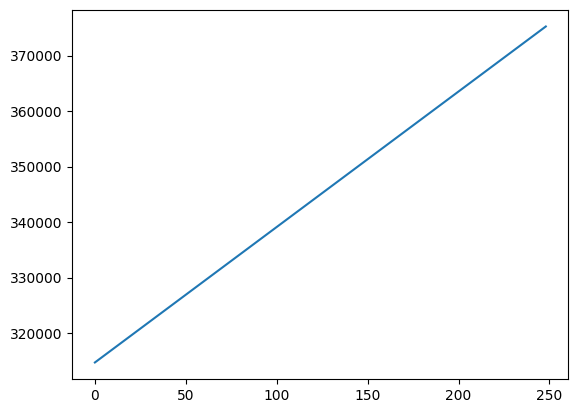

In [20]:
plt.figure()
plt.plot(freq_vec)

### Step 1. Perform a BEPFM measurement

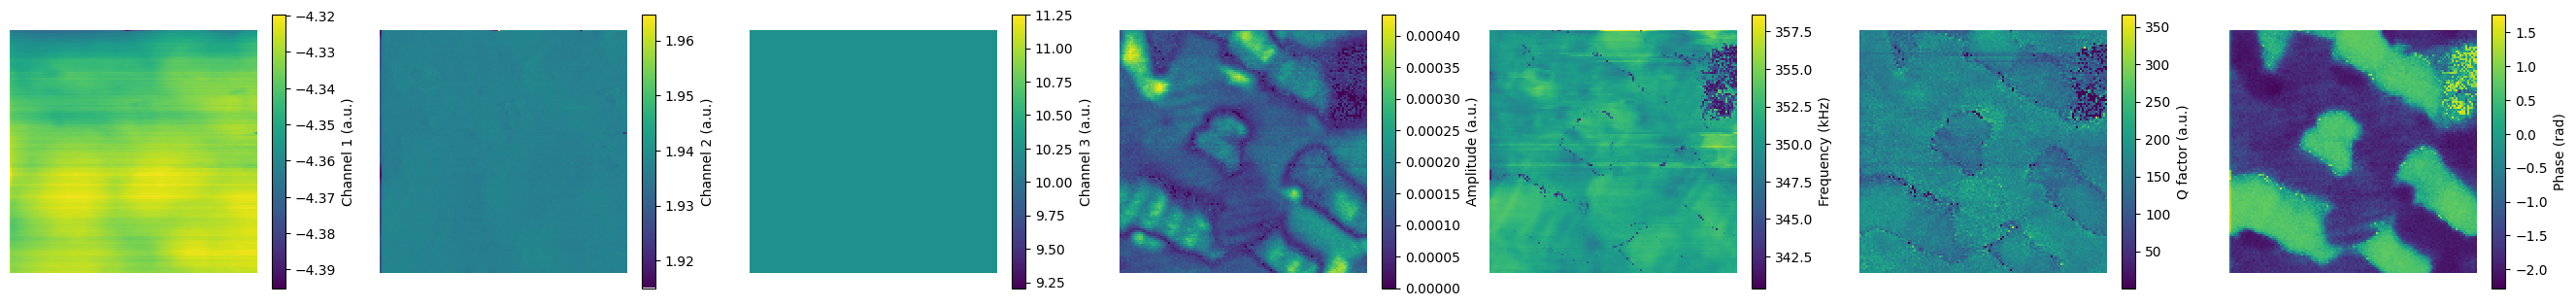

 [progress: 0:11:47] |************************************* | (ETA:   0:00:05) 

Channels dataset is of shape (3, 128, 128, 1)
Complex dataset is of shape (128, 128, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


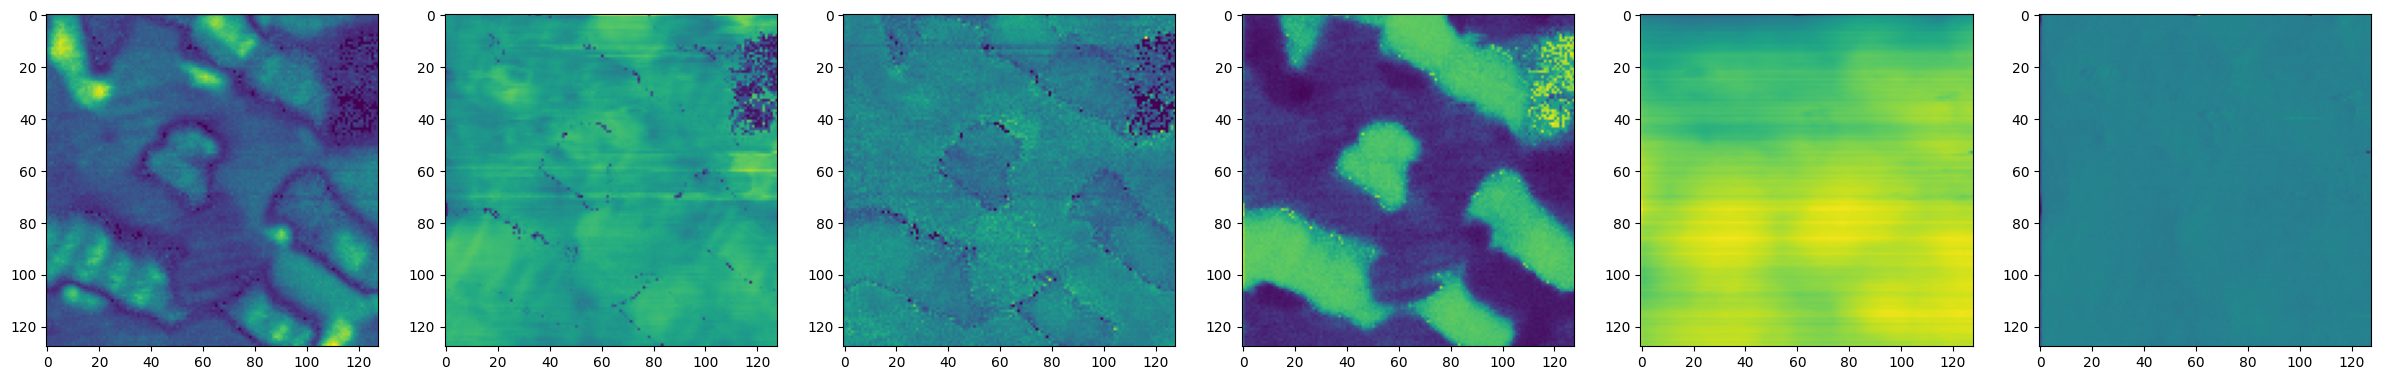

In [21]:
dset_pfm, dset_chns, dset_cs = newexp.raster_scan(raster_parms_dict = {"scan_pixel": 128, "scan_x_start": -1.0,
                                                                       "scan_y_start": -1.0,"scan_x_stop": 1.0,
                                                                       "scan_y_stop": 1.0}, file_name = "BEPFM_PTO_2um")

f, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(1, 6, figsize = (30, 5), dpi = 100)
ax1.imshow(dset_pfm[:,:,0])
ax2.imshow(dset_pfm[:,:,1])
ax3.imshow(dset_pfm[:,:,2])
ax4.imshow(dset_pfm[:,:,3])
ax5.imshow(dset_chns[0,:,:])
ax6.imshow(dset_chns[1,:,:])
plt.show()

### Step 2. Prepare structure patch

In [22]:
# struc_img = np.load("structure_image.npy")
# print(struc_img.shape)

In [23]:
# normalize structure data
norm_ = lambda x: (x - x.min()) / (x.max() - x.min())
# norm_ = lambda x: np.clip((x-np.percentile(x,5)) / (np.percentile(x, 95) - np.percentile(x,5)), 0, 1) ##  (x - x.min()) / (x.max() - x.min())
struc_img = np.asarray(dset_pfm[:,:,0])          # set structure image
struc_img = norm_(struc_img)   # normalize

np.save('structure_image.npy', struc_img)  # send this to GPU server later

print ("Structure image shape:", struc_img.shape)

Structure image shape: (128, 128)


In [24]:
# # normalize structure data
# norm_ = lambda x: (x - x.min()) / (x.max() - x.min())
# struc_img, _, _ = extract_beps_data(r"" + 'inputs/' + "data/PTO_BEPS_0d85um.npz")
# struc_img = norm_(struc_img)   # normalize

# np.save('structure_image.npy', struc_img)  # send this to GPU server later

# print ("Structure image shape:", struc_img.shape)

In [25]:
## to convert (x, y) in range ([-1, 1], [-1, 1])
height, width = struc_img.shape  # e.g., (256, 256)
print(height, width)
def pixel_to_real_coord(pixel_coord):
    row, col = pixel_coord
    x_real = -1 + 2 * (col / (width - 1))
    y_real = -1 + 2 * (row / (height - 1))
    return np.array([x_real, y_real])

128 128


Patch shape: (11881, 20, 20)
Coords list shape:  (11881, 2)
[10. 30.]


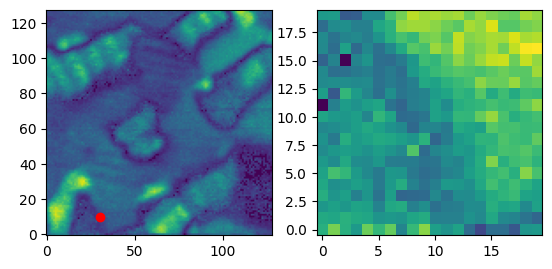

In [26]:
# prepare structure image patches
coordinates = get_coord_grid(struc_img, 1)

# patch size
window_size = 20
pix = struc_img.shape[1] - window_size + 1

# extract subimage for each point on a grid
features_all, coords, _ = extract_subimages(struc_img, coordinates, window_size)
features_all = features_all[:,:,:,0]

print("Patch shape:", features_all.shape)
print("Coords list shape: ", coords.shape)

# plot structure image and an example patch
_, (ax1, ax2) = plt.subplots(1, 2, dpi = 100)
k = 20 
print(coords.reshape(-1, 2)[k])
ax1.imshow(struc_img, origin = "lower")
ax1.scatter(coords.reshape(-1, 2)[k, 1], coords.reshape(-1, 2)[k, 0], c = 'r')
ax2.imshow(features_all[k], origin = "lower")
plt.show()

In [27]:
coords[1], pixel_to_real_coord(coords[1])

(array([10., 11.]), array([-0.82677165, -0.84251969]))

In [28]:
for i, c in enumerate(coords[:5]):
    print(i, c, pixel_to_real_coord(c))

0 [10. 10.] [-0.84251969 -0.84251969]
1 [10. 11.] [-0.82677165 -0.84251969]
2 [10. 12.] [-0.81102362 -0.84251969]
3 [10. 13.] [-0.79527559 -0.84251969]
4 [10. 14.] [-0.77952756 -0.84251969]


In [29]:
# np.save('structure_image.npy', struc_img)

### Step 3. Send struc_img.npy to GPU server via sftp

```{admonition} Run on GPU server
Run below code on GPU server.
```
### Step 4. Install, import, and define help functions

In [30]:
# Please run this code @ GPU server
# -------------------------------------------------------------------

import time
import os
import numpy as np
import pylab as pl
import torch
import gpytorch
# import botorch
import atomai as aoi
from atomai import utils
# from scipy.signal import find_peaks
# from sklearn.model_selection import train_test_split
from typing import Union, Type
# from mlsocket import MLSocket

In [31]:
import numpy as np
from atomai.utils import get_coord_grid, extract_patches_and_spectra, extract_patches, extract_subimages
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, ListedColormap
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
from typing import List, Tuple
import random
from torch.utils.data import DataLoader, Dataset, random_split
# import optuna
from utils import *
from models import *
import copy
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
import os
import pickle
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# !pip install scipy
from scipy.stats import qmc
import numpy as np

### Step 5. Prepare image patches

In [33]:
#Dp BEPS Grid 5x5 to obtain some reference spectra

#Let's do grid BEPS
dset_pfm, dset_chns, dset_cs,_ = newexp.do_beps_grid(
    beps_parms_dict = {"amplitude_V_00":8, "step_per_cycle_03": 64, "num_cycles_04": 2, 
                                                 "measure_loops_07": 0, "transition_time_s_08": 1E-3},
    beps_grid_parms_dict = {"range_x": [-1, 1], 
                                                 "range_y": [-1, 1],
                                                 "pixel_num_x": 5, 
                                                 "pixel_num_y": 5},
    file_name = "beps_grid_5x5_8V_2c")


 [progress: 0:01:36] |************************************  | (ETA:   0:00:04) 

Channels dataset is of shape (25, 3, 256)
Complex dataset is of shape (25, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


In [ ]:
vdc_vec = np.array(dset_pfm)
plt.figure()
plt.plot(vdc_vec, 'ro-')
         
vdc_one_cycle = vdc_vec[64:128]
amp_oc_OF = dset_chns[:,:,:][:,:,1::2][:,:,64:128]

In [37]:
vdc_one_cycle.shape, amp_oc_OF.shape

((64,), (25, 4, 64))

In [ ]:
fig, axes = plt.subplots(nrows=1,ncols=2,figsize=(10,5))
colors = plt.cm.get_cmap('inferno', 25)
response_of_median = np.sum(np.median(np.array(amp_oc_OF[:,0,:]), axis=(0)))
std_median = np.std(np.median(np.array(amp_oc_OF[:,0,:]), axis=(0)))

for ind in range(25):
    response_loop = amp_oc_OF[ind,0,:]
    color_loop = colors(ind)
#     if np.sum(response_loop) > response_of_median + 15*std_median:
# #         print(ind)
#         color_loop = 'm'
#     else:
#         color_loop = colors(ind)
    
    axes[0].plot(vdc_one_cycle, amp_oc_OF[ind,0,:],color = color_loop)
    axes[1].plot(vdc_one_cycle, amp_oc_OF[ind,-1,:],color = colors(ind))
    
axes[0].set_title('Amplitude')
axes[1].set_title('Phase')

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(15,10))
for ind, ax in enumerate(axes.flat):
    ax.plot(vdc_one_cycle, amp_oc_OF[ind,0,:], label = 'amplitude')
    ax2 = ax.twinx()
    ax2.plot(vdc_one_cycle, amp_oc_OF[ind,-1,:], 'r-', label = 'phase')
    #plt.legend(loc='best')
fig.tight_layout()

In [ ]:
vdc_one_cycle.shape

```{admonition} Run on local PC
Run below code on microscope computer.
```

### Step 6. Do first BEPS at random location

In [42]:
seed = 42
set_seed()
total_samples = len(features_all)
num_train = 40 ## initial train
spectra_dim = int(vdc_one_cycle.shape[0])

In [ ]:
#Defien BEPS parameters
newexp.define_BEPS_parameters(beps_parms_dict = {"amplitude_V_00": 8, "step_per_cycle_03": 64, "num_cycles_04": 2, 
                                                 "measure_loops_07": 0, "transition_time_s_08": 1E-3})
def do_beps(index): ## place holder
    real_coords = pixel_to_real_coord(coords[index]) ## converting both (row, col) to be within [-1, 1] range

    ## use real_coords
    vdc_vector, dset_imgs, dset_chns, _ = newexp.do_beps_specific(file_name = "BEPS_point", 
                                                                          coordinates=real_coords)
    dset_complex_spectra = np.array(newexp.VI.getcontrolvalue('BEPS_VS_indicator_cluster')[1])
    dset_imgs = np.array(dset_imgs)
    # y_raw = dset_imgs[0,0,1::2][64:128]*np.cos(dset_imgs[0,3,1::2][64:128])
    
    #######################################################################################
    
    beps_cpx_spectrogram = np.array(dset_complex_spectra) 
    print('===', beps_cpx_spectrogram.shape)
    global_lower_bounds = [1E-6, freq_vec.min(), 50, -2*np.pi]
    global_upper_bounds = [1E-3, freq_vec.max(), 500, 2*np.pi]
    r2_list = []
    fitted_curves = []
    fitted_params = []
    for i in range(beps_cpx_spectrogram.shape[0]):
        y_sho = beps_cpx_spectrogram[i,:, 0] + 1j*beps_cpx_spectrogram[i,:, 1]
        y_concat =   np.concatenate([np.real(y_sho), np.imag(y_sho)])
#         try:
        p0 = SHOestimateGuess(freq_vec, y_sho) ## here y is complex
        lower_bounds = [min(lb, p) - 1e-12 for lb, p in zip(global_lower_bounds[:3], p0[:3])] + [global_lower_bounds[3]]
        upper_bounds = [max(ub, p) + 1e-12 for ub, p in zip(global_upper_bounds[:3], p0[:3])] + [global_upper_bounds[3]]
        popt, _ = curve_fit(SHO_fit_flattened, freq_vec, y_concat, p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=1000) ## here y is concat(real + imag)
        y_fit = SHO_fit_flattened(freq_vec, *popt)
        r2 = calc_r2_score(y_concat, y_fit)
#         except Exception:
#             popt = [0, 0, 0, 0]
#             y_fit = np.zeros_like(y_concat)
#             r2 = 0            
        r2_list.append(r2)
        fitted_curves.append(y_fit)
        fitted_params.append(popt)
    mean_r2 = float(np.nanmean(r2_list))
    r2_clean = np.array(r2_list)[~np.isnan(np.array(r2_list))]
    mean_r2_bottom = float(np.mean(r2_clean[r2_clean <= np.percentile(r2_clean, 5)]))
    ## ------------------------------------------------------------------------------------
    amps = np.array([p[0] for p in fitted_params])      # length = num_bias
    freqs = np.array([p[1] for p in fitted_params])
    qs = np.array([p[2] for p in fitted_params])
    phases = np.array([p[3] for p in fitted_params]) 
    num_steps_per_cycle = np.array(newexp.VI.getcontrolvalue('Initialize_BEPS_VS_control_cluster')[3])
    roll_number = int(num_steps_per_cycle*0.25)
    
#     y_raw = (amps * np.cos(phases))[1::2][64:128]
#     return beps_cpx_spectrogram, vdc_vec, amps, phases, dset_complex_spectra

    vdc_vec = np.roll(vdc_vector, roll_number)
    amps = np.roll(amps, roll_number)
    phases = np.roll(phases, roll_number)
    y_raw = projectLoop(vdc_vec, amps[1::2], phases[1::2]) ## [1::2][64:128]
    return y_raw, mean_r2, vdc_vec, amps, phases, mean_r2_bottom     
    #######################################################################################
    # return y_raw    
    
    ## this should return the correspnding spectra

In [ ]:
np.random.seed(seed)
indices_train = np.random.choice(total_samples, size=num_train, replace=False)
##
# y_train_raw = np.array([do_beps(idx) for idx in indices_train])
results = [do_beps(idx) for idx in indices_train]

In [47]:
results[-1][0]['Projected Loop'].shape

(128,)

In [48]:
len(results[0])

6

In [ ]:
y_train_raw = np.array([r[0]['Projected Loop'] for r in results])     # projected loops
vdc_raw = np.array([r[2] for r in results])
amp_raw = np.array([r[3] for r in results])
phase_raw = np.array([r[4] for r in results])

r2_train_vals = [r[-1] for r in results]   # mean R² values
##
y_train_normalize = norm_0to1(y_train_raw)
print(y_train_normalize.shape, len(r2_train_vals))

In [ ]:
plt.hist(r2_train_vals)

In [61]:
import pickle
info = {}
info['indices_train'] = indices_train
info['y_train_raw'] = y_train_raw
info['vdc_raw'] = vdc_raw
info['amp_raw'] = amp_raw
info['phase_raw'] = phase_raw
info['y_train_normalize'] = y_train_normalize
info['r2_train_vals'] = r2_train_vals
pickle.dump(info, open('info.pkl', 'wb'))

In [62]:
with open('info.pkl', 'rb') as f:
    info = pickle.load(f)

In [63]:
indices_train = info['indices_train']
y_train_raw = info['y_train_raw']
vdc_raw = info['vdc_raw']
amp_raw = info['amp_raw']
phase_raw = info['phase_raw']
y_train_normalize = info['y_train_normalize']
r2_train_vals = info['r2_train_vals']

In [64]:
spectra_dim = y_train_raw.shape[1]

In [ ]:
len(indices_train), num_train, spectra_dim, vdc_raw.shape, amp_raw.shape, phase_raw.shape

In [ ]:
print(y_train_normalize.shape, len(r2_train_vals))

In [ ]:
vdc_one_cycle = results[0][2]
vdc_one_cycle.shape

In [ ]:
fig, axes = plt.subplots(nrows=5,ncols=2,figsize=(18,18))

for ind,ax in enumerate(axes.flat):
    response_loop = y_train_raw[ind+10,:]
    ax.plot(vdc_one_cycle, response_loop[:])
    ax.plot(vdc_one_cycle, response_loop[:])
    ax.set_title(f'index - {ind+10}, {r2_train_vals[ind+10]:.2f}')
## 16, 19, 22, 25, 27

### Step 7. Request connection to GPU server and start Active Learning with Gated-GP exploration

```{admonition} Run on GPU server
Run below code on GPU server.
```


### Step 8. Connect to local PC and start Active Learning with Gated-GP exploration

In [ ]:
coordinates = coords 
X = features_all
indices = np.arange(len(X))
dim_in = X[0].shape  
dim_out = spectra_dim 
print(X.shape, indices.shape, coordinates.shape, dim_in, dim_out)
##
##
init_lr = 2e-4 
init_num_epochs = 100 
batch_size = 10
latent_dim = 10
alpha = 0.40 ## exploit error model?
beta = 0.20 ## 0 ## explore distant samples?
gamma = 0.40 ## 0 ## explore high representative samples?
wdecay1=1e-5 
wloss1=2 
beta1=0.05
nb_filters_enc=32
nb_filters_dec=32
dropout=0.01
conv1_channels=16
conv2_channels=32

In [75]:
##
X_train = None ##
y_train = None ## 
next_indices = None
X_test = None ##
indices_test = None ##
gp = None

In [76]:

r2_threshold = np.percentile(r2_train_vals, 30) ## 0.3000
r2_threshold_pred = np.percentile(r2_train_vals, 30) ## 0.3000
num_sample_exp = 10
exploration_steps = 10 ## 15

In [77]:
r2_threshold

0.4929408945987811

In [ ]:
sorted(r2_train_vals)

In [79]:
def train_im2spec(model, train_data, val_data, device, num_epochs=1000, lr=1e-3, batch_size=32, wdecay=1e-4, wloss=2, beta=0.05):

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    if val_data:
        val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    else:
        val_loader = None
    

    def weighted_mse_loss(pred, target, x=2):  # x is the exponent parameter
        weights = target ** x  # Higher target → More weight
        return torch.mean(weights * (pred - target) ** 2)
        
    def weighted_smooth_l1_loss(pred, target, beta=0.1, x=2):
        """
        Weighted Smooth L1 Loss (Huber Loss) that gives higher weight to larger targets.
        """
        weights = target ** x  # Higher target → More weight
        huber_loss = torch.where(
            torch.abs(pred - target) < beta,
            0.5 * (pred - target) ** 2 / beta,  # Quadratic region (MSE-like)
            torch.abs(pred - target) - 0.5 * beta  # L1 region
        )
        # print(target.shape, pred.shape) ## [16, 121] ==> the weight has also a dimension of [16, 121]     
        return torch.mean(weights * huber_loss)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wdecay)
    # criterion = lambda pred, target: weighted_mse_loss(pred, target, x=wloss) ## nn.MSELoss() ## nn.L1Loss()
    criterion = lambda pred, target: weighted_smooth_l1_loss(pred, target, beta=beta, x=wloss)
    

    ## linear decay Learning Rate Scheduler (starts at lr, reduces to 0.1 * lr at last epoch)
    lr_lambda = lambda epoch: 1 - (epoch / num_epochs) * 0.9  # Reduces from lr → 0.1 * lr
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    best_val_loss = float("inf")
    best_model_state = None

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Validation Step
        if val_loader:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch_x, batch_y in val_loader:
                    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                    preds = model(batch_x)
                    loss = criterion(preds, batch_y)
                    val_loss += loss.item()
    
            val_loss /= len(val_loader)
    
            # Adjust Learning Rate
            scheduler.step()
            
            # Track best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = model.state_dict()
    
            if epoch%(num_epochs//4)==0:
                log_message(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}')

    # Load the best model state before returning
    if val_loader:
        model.load_state_dict(best_model_state)
    return model

def train_error_model(model, train_data, val_data, device, num_epochs=1000, lr=1e-3, batch_size=32, wdecay=1e-4, wloss=2, beta=0.05):

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    if val_data:
        val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    else:
        val_loader = None

    def weighted_mse_loss(pred, target, x=2):  # x is the exponent parameter
        weights = target ** x  # Higher target → More weight
        return torch.mean(weights * (pred - target) ** 2)

    def weighted_smooth_l1_loss(pred, target, beta=0.1, x=2):
        
        # #################################################################        
        # """
        # Weighted Smooth L1 Loss (Huber Loss)
        # - If target has shape [B, 121], apply small weights to first 20 dims
        # - If target has shape [B, 1], apply weight = 1
        # """
        # # Multi-dimensional case (e.g., [B, 121])
        # if target.ndim == 2 and target.shape[1] > 1:
        #     dim_weights = torch.cat([
        #         torch.full((20,), 1e-4, device=target.device),
        #         torch.ones((target.shape[1] - 20,), device=target.device)
        #     ])  # shape: [121]
        #     weights = dim_weights.unsqueeze(0).expand_as(target)  # shape: [B, 121]
        # else:
        #     # 1D case (e.g., [B, 1])
        #     weights = torch.ones_like(target)  # or simply: weights = torch.ones_like(target)
        # #################################################################

        abs_diff = torch.abs(pred - target)        
        weights = torch.full_like(target, fill_value=x)
        huber_loss = torch.where(
            abs_diff < beta,
            0.5 * abs_diff ** 2 / beta,
            abs_diff - 0.5 * beta
        )
        return torch.mean(weights * huber_loss)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wdecay)
    # criterion = lambda pred, target: weighted_mse_loss(pred, target, x=wloss) ## nn.MSELoss() ## nn.L1Loss()
    criterion = lambda pred, target: weighted_smooth_l1_loss(pred, target, beta=beta, x=wloss)
    
    

    ## linear decay Learning Rate Scheduler (starts at lr, reduces to 0.1 * lr at last epoch)
    lr_lambda = lambda epoch: 1 - (epoch / num_epochs) * 0.9  # Reduces from lr → 0.1 * lr
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    
    best_val_loss = float("inf")
    best_model_state = None

    list_train_loss = []
    train_loss = None
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        list_train_loss.append(train_loss)

        # Validation Step
        if val_loader:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch_x, batch_y in val_loader:
                    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                    preds = model(batch_x)
                    loss = criterion(preds, batch_y)
                    val_loss += loss.item()
    
            val_loss /= len(val_loader)
    
            # Adjust Learning Rate
            scheduler.step()
            
            # Track best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = model.state_dict()
                
            if epoch%(num_epochs//4)==0:
                log_message(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}')

    # Load the best model state before returning
    if val_loader:
        model.load_state_dict(best_model_state)
    return model, list_train_loss

In [80]:
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

Active Learning with Gated-GP starts
##########----step 0/10----##########
Using ---> RANDOM SAMPLING
Send next point index of test set and actual next point index:  [ 1017  9158  1056  7746  5194  5125  8256  1115  2385 10163] [ 1018  9187  1057  7770  5207  5138  8283  1116  2387 10199]


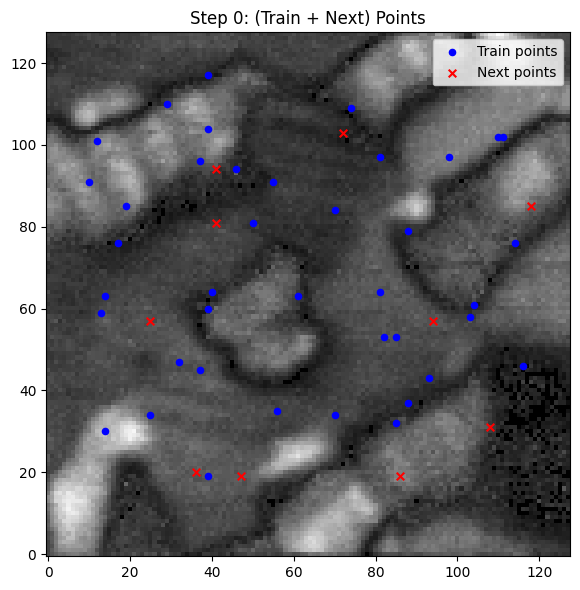

predicted point ready (next_indices)  [ 1018  9187  1057  7770  5207  5138  8283  1116  2387 10199]


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)


...

=== (256, 249, 2)


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)
measurement done
y_train_normalize shape is: (50, 128)
##########----step 1/10----##########
Using ---> RANDOM SAMPLING
Send next point index of test set and actual next point index:  [ 9243  4760  4384  7615  9733  2158  5324  5915  6452 10959] [ 9282  4777  4399  7645  9775  2162  5345  5941  6479 11008]


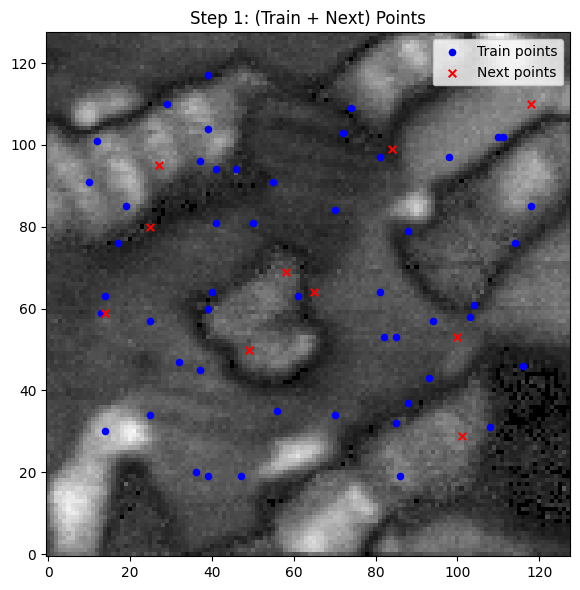

predicted point ready (next_indices)  [ 9282  4777  4399  7645  9775  2162  5345  5941  6479 11008]


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)


...

=== (256, 249, 2)


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)
measurement done
y_train_normalize shape is: (60, 128)
##########----step 2/10----##########
Using ---> RANDOM SAMPLING
Send next point index of test set and actual next point index:  [ 8277  8956  3269  5268  4189  1952  7461 10557 11472   802] [ 8319  9000  3281  5290  4205  1956  7496 10613 11531   802]


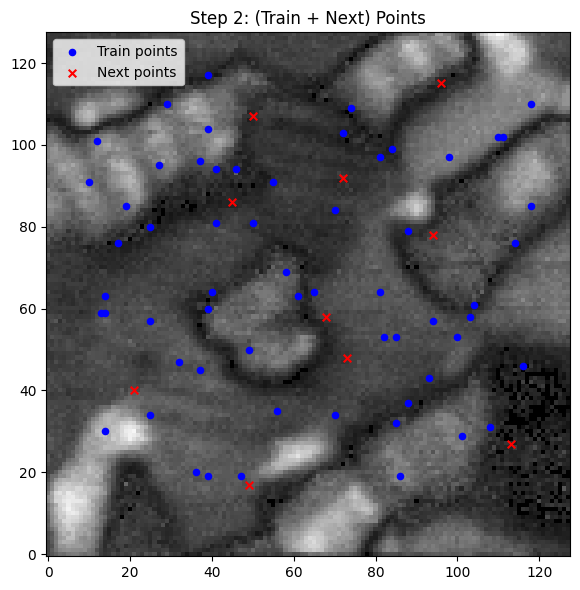

predicted point ready (next_indices)  [ 8319  9000  3281  5290  4205  1956  7496 10613 11531   802]


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)


...

=== (256, 249, 2)


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)
measurement done
y_train_normalize shape is: (70, 128)
##########----step 3/10----##########
Using ---> RANDOM SAMPLING
Send next point index of test set and actual next point index:  [11424  4851  8792  3847  8062  8774  4328 10695  1820 10890] [11492  4875  8842  3864  8107  8823  4348 10760  1825 10957]


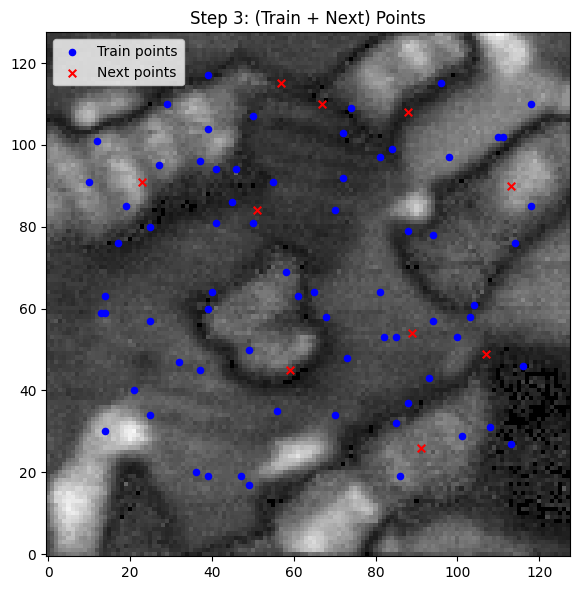

predicted point ready (next_indices)  [11492  4875  8842  3864  8107  8823  4348 10760  1825 10957]


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)


...

=== (256, 249, 2)


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)
measurement done
y_train_normalize shape is: (80, 128)
##########----step 4/10----##########
Using ---> RANDOM SAMPLING
Send next point index of test set and actual next point index:  [ 8263  9824  2675  7900 11091  7431  5157  1895  6657  3893] [ 8316  9890  2688  7949 11168  7475  5186  1901  6699  3912]


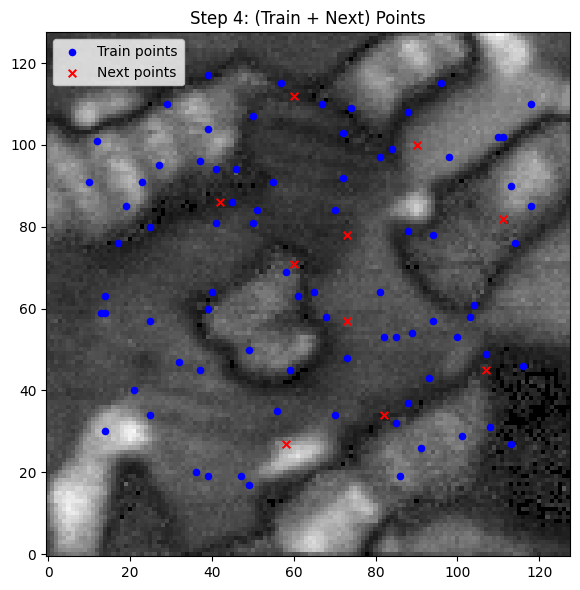

predicted point ready (next_indices)  [ 8316  9890  2688  7949 11168  7475  5186  1901  6699  3912]


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)


...

=== (256, 249, 2)


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)
measurement done
y_train_normalize shape is: (90, 128)
##########----step 5/10----##########
Using ---> RANDOM SAMPLING
Send next point index of test set and actual next point index:  [8042 3397   86 2356 2822 1647 7504 9815 9395 9488] [8098 3415   86 2366 2838 1652 7555 9889 9466 9560]


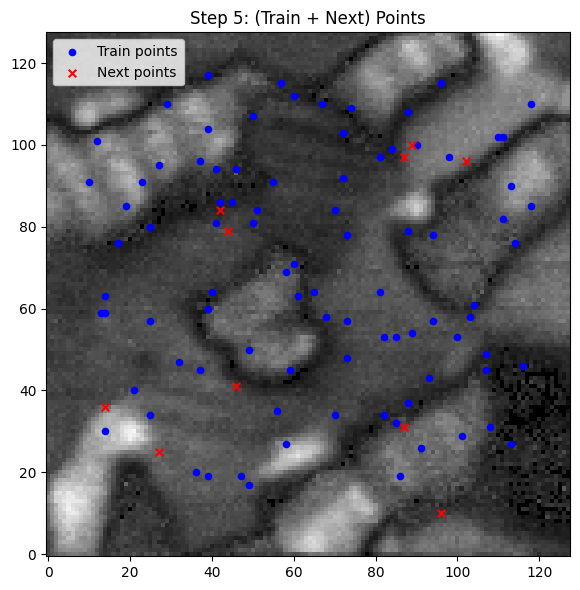

predicted point ready (next_indices)  [8098 3415   86 2366 2838 1652 7555 9889 9466 9560]


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)


...

=== (256, 249, 2)


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)
measurement done
y_train_normalize shape is: (100, 128)
##########----step 6/10----##########
Using ---> RANDOM SAMPLING
Send next point index of test set and actual next point index:  [2890 7873 6695  438 5177 1646 5549 5951 1348 7709] [2910 7934 6747  439 5216 1653 5593 6001 1354 7768]


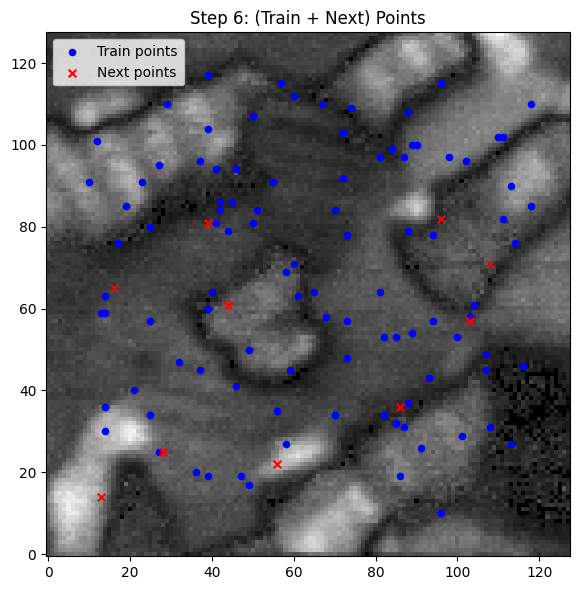

predicted point ready (next_indices)  [2910 7934 6747  439 5216 1653 5593 6001 1354 7768]


 [progress: 0:00:03] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)


...

=== (256, 249, 2)


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)
measurement done
y_train_normalize shape is: (110, 128)
##########----step 7/10----##########
Using ---> RANDOM SAMPLING
Send next point index of test set and actual next point index:  [ 4089  7092  3575 11565  3255  9350  6577  5139  2525   362] [ 4122  7152  3602 11674  3280  9438  6635  5180  2543   363]


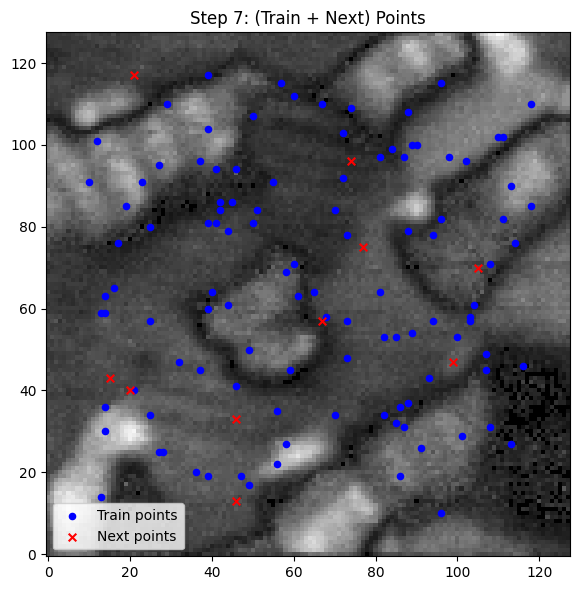

predicted point ready (next_indices)  [ 4122  7152  3602 11674  3280  9438  6635  5180  2543   363]


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)


...

=== (256, 249, 2)


 [progress: 0:00:03] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)
measurement done
y_train_normalize shape is: (120, 128)
##########----step 8/10----##########
Using ---> RANDOM SAMPLING
Send next point index of test set and actual next point index:  [ 9217  5104  7812  5937 10784  3450  6549 11714  7780  1484] [ 9312  5150  7890  5999 10896  3480  6613 11834  7858  1493]


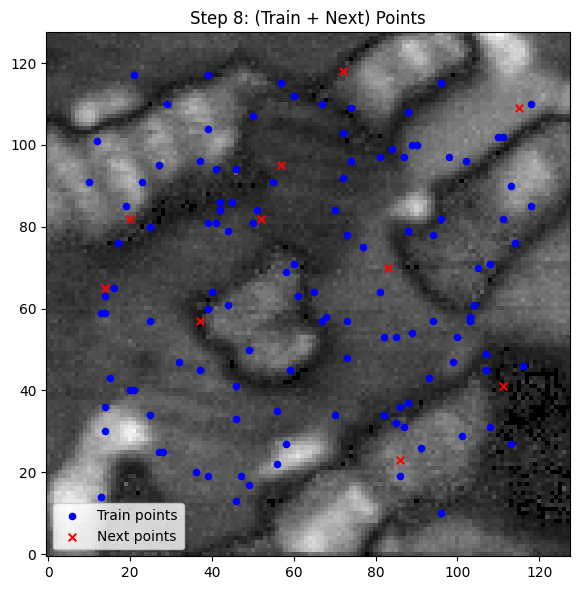

predicted point ready (next_indices)  [ 9312  5150  7890  5999 10896  3480  6613 11834  7858  1493]


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)


...

=== (256, 249, 2)


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)
measurement done
y_train_normalize shape is: (130, 128)
##########----step 9/10----##########
Using ---> RANDOM SAMPLING
Send next point index of test set and actual next point index:  [ 1894 10581  5887 11023  1057  8483  8183  8423  5425  9060] [ 1908 10699  5951 11147  1064  8577  8274  8517  5483  9159]


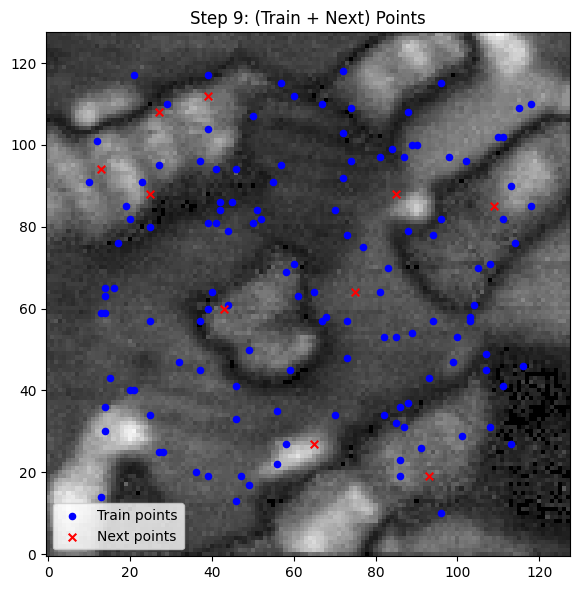

predicted point ready (next_indices)  [ 1908 10699  5951 11147  1064  8577  8274  8517  5483  9159]


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)


...

=== (256, 249, 2)


 [progress: 0:00:04] |                                      | (ETA:  --:--:--) 

Channels dataset is of shape (1, 3, 256)
Complex dataset is of shape (1, 256, 249, 2)


C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',
C:\Users\Asylum User\AppData\Roaming\Python\Python312\site-packages\pyNSID\io\hdf_utils.py:381: FutureWarning: validate_h5_dimension may be removed in a future version
  warn('validate_h5_dimension may be removed in a future version',


=== (256, 249, 2)
measurement done
y_train_normalize shape is: (140, 128)


In [81]:
import numpy as np
rng = np.random.default_rng(seed=42)
print('Active Learning with Gated-GP starts')
for i in range(exploration_steps):
    print("##########----step {}/{}----##########".format(i, exploration_steps))

    # starttime = time.time()
    device = torch.device('cpu')   
    ####################################################################
    ## forming up => y_train, indices_train, X_train, 
    ##               y_train_gp, indices_train_gp, 
    ##               gp
    ##               X_test, indices_test
    indices_train = np.array(indices_train)    
    if i == 0:
        y_train = np.array(np.asarray(y_train_normalize))
        X_train = X[indices_train]
        
    else:
        y_train = np.vstack([y_train, np.asarray(y_train_normalize[-num_sample_exp:])])
        X_train = np.vstack([X_train, X[next_indices]])   
    ##    
    mask = np.ones(X.shape[0], dtype=bool)
    mask[indices_train.flatten()] = False
    X_test = X[mask]
    indices_test = np.where(mask)[0]              
    ####################################################################
    ####################################################################
    ## forming up => training of gp, cleaning X and y for training, 
    ##               training of im2spec, training of error model
    ## QC fit
    ## QC cleanUp 
    ##
    ####################################################################
    ####################################################################
    ## forming up => active learning/update
    indices_next = rng.choice(len(X_test), num_sample_exp, replace=False)
    print('Using ---> RANDOM SAMPLING')
    selected_indices = indices_test[indices_next] ## indices_next is local to indices_test (relative to indices_test, not global)        
    ####################################################################
    ####################################################################
    ## forming up => sending points to client, saving record
    
    print("Send next point index of test set and actual next point index: ", indices_next, selected_indices)
    np.savez(
        os.path.join('', "record{}.npz".format(i)), 
        ##
        ## 1 plot (currentPoints + nextPoints)
        coords = coords,        
        indice_train = indices_train,        
        nextpoint=selected_indices,                
        ## 4 plots (err, dis, sim, acq)
        indices_next=indices_next,
        indice_test=indices_test,                
        ## others
        x_train = X_train, 
        y_train = y_train, 
        #
        y_train_raw=y_train_raw,
        vdc_raw=vdc_raw,
        amp_raw=amp_raw,
        phase_raw=phase_raw,
        #
        vdc_vec=vdc_vec,
        vdc_one_cycle=vdc_one_cycle,                
        ##
    )
    
    ##################################################################################################################################
    ##################################################################################################################################
    ##################################################################################################################################
    ## interactive
    ## output
    train_coords = coords.reshape(-1, 2)[indices_train]
    next_coords = coords.reshape(-1, 2)[selected_indices]
    test_coords = coords.reshape(-1, 2)[indices_test]
    ## plot1: current point+ next point    
    # Plotting
    fig, ax1 = plt.subplots(1, 1, figsize=(6, 6), dpi=100)    
    # Subplot 1: Train + Next points
    ax1.imshow(struc_img, origin='lower', cmap='gray')
    ax1.scatter(train_coords[:, 1], train_coords[:, 0], c='blue', s=20, label='Train points')
    ax1.scatter(next_coords[:, 1], next_coords[:, 0], c='red', s=30, marker='x', label='Next points')
    ax1.set_title(f'Step {i}: (Train + Next) Points')
    ax1.legend()
    plt.tight_layout()
    plt.savefig(f"record_{i}.png", bbox_inches='tight', dpi=300)
    plt.show()
    
    ## receiving...
    next_indices = selected_indices
    ## updating...
    print("predicted point ready (next_indices) ", next_indices)        
    ###### Do BEPS Measurement at predicted location ########
    next_indices = np.array(next_indices)                
    ##
    # new_spec = np.array([do_beps(idx) for idx in next_indices])
    results = [do_beps(idx) for idx in next_indices]
    new_spec = np.array([r[0]['Projected Loop'] for r in results]) 
    new_vdc = np.array([r[2] for r in results])        
    new_amp = np.array([r[3] for r in results])
    new_phase = np.array([r[4] for r in results])
    ##
    print("measurement done")        
    y_train_raw = np.vstack([y_train_raw, new_spec])
    vdc_raw = np.vstack([vdc_raw, new_vdc])        
    amp_raw = np.vstack([amp_raw, new_amp])
    phase_raw = np.vstack([phase_raw, new_phase])    
    y_train_normalize = norm_0to1(y_train_raw)
    print(f'y_train_normalize shape is: {y_train_normalize.shape}')
    indices_train = np.hstack([indices_train, next_indices])
    

    # plotting...
    next_coords = coords[next_indices]         
    # clear_output(wait=True)
    # plt.figure()
    # plt.imshow(struc_img, origin='lower')
    # plt.scatter(next_coords[:, 1], next_coords[:, 0], c='r') 
    # plt.title("Next acquisition points")
    # plt.show()

    # print("time in this step: ", time.time()-starttime)

    
    ####################################################################

In [85]:
# print(y_train_raw.shape, new_spec.shape, indices_train.shape, indices_train_gp.shape)

In [ ]:
#Dp BEPS Grid 50x50 to obtain some reference spectra

#Let's do grid BEPS
dset_pfm, dset_chns, dset_cs,_ = newexp.do_beps_grid(
    beps_parms_dict = {"amplitude_V_00":8, "step_per_cycle_03": 64, "num_cycles_04": 2, 
                                                 "measure_loops_07": 0, "transition_time_s_08": 1E-3},
    beps_grid_parms_dict = {"range_x": [-1, 1], 
                                                 "range_y": [-1, 1],
                                                 "pixel_num_x": 16, 
                                                 "pixel_num_y": 16},
    file_name = "beps_grid_16x16_8V")